# Hybrid Aspect-Aware Product Recommender

Kaggle notebook for `Product_Reviews_Modified.xlsx` using multilingual dense retrieval, char n-gram TF-IDF, aspect reranking, hard negatives, and a learned neural reranker.

In [7]:
!pip -q install transformers scikit-learn openpyxl joblib

In [8]:
from __future__ import annotations

import json, math, os, random, re, unicodedata
from collections import defaultdict
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from torch.utils.data import DataLoader, Dataset, TensorDataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

DATA_PATH = Path('/kaggle/input/datasets/fardeenhaque/products-modified/Product_Reviews_Modified.xlsx')
WORKDIR = Path('/kaggle/working/hybrid_aspect_recommender')
MODEL_DIR = WORKDIR / 'dense_e5_best'
ARTIFACT_DIR = WORKDIR / 'artifacts'
WORKDIR.mkdir(parents=True, exist_ok=True); ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

BASE_MODEL = 'intfloat/multilingual-e5-base'
MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 0.001
TRAIN_BATCH_SIZE = 32
ENCODE_BATCH_SIZE = 128
MAX_LENGTH = 128
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
TEMPERATURE = 0.05
MAX_DENSE_PAIRS = 60000
MAX_RERANKER_QUERIES = 18000
NEGATIVES_PER_QUERY = 8
RERANKER_EPOCHS = 80
RERANKER_PATIENCE = 8
TOP_K = 10
NUM_WORKERS = 0

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found: {DATA_PATH}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('dataset:', DATA_PATH)
print('workdir:', WORKDIR)
print('device:', DEVICE, '| gpu_count:', torch.cuda.device_count())

dataset: /kaggle/input/datasets/fardeenhaque/products-modified/Product_Reviews_Modified.xlsx
workdir: /kaggle/working/hybrid_aspect_recommender
device: cuda | gpu_count: 2


## Load, clean, and inspect the workbook

In [9]:
BANGLA_DIGITS = str.maketrans('০১২৩৪৫৬৭৮৯', '0123456789')

GENERIC_REVIEWS = {
    'good','nice','ok','okay','fine','excellent','best','thanks','thank you','recommended',
    'good product','nice product','very good','best product','valo','bhalo','onek valo',
    'খুব ভালো','ভালো','ভাল','ভালো পণ্য','জোস','সুন্দর','ধন্যবাদ'
}

META_ALIASES = {
    'marketplace': ['marketplace', 'market_place', 'daraz'],
    'category': ['category'],
    'product_link': ['product_link', 'productlink'],
    'product_name': ['product_name', 'productname'],
    'brand': ['brand', 'brand_'],
    'price_bdt': ['price_bdt', 'pricebdt'],
    'overall_rating': ['overall_rating', 'overallrating'],
    'reviews': ['reviews', 'review'],
    'sentiment': ['sentiment'],
}
META_COLS = set(META_ALIASES) | {'sheet_name', 'product_id', 'aspect_cols'}

def normalize_text(x) -> str:
    if pd.isna(x): return ''
    x = unicodedata.normalize('NFKC', str(x)).replace('\u200c', ' ').replace('\xa0', ' ')
    x = re.sub(r'\s+', ' ', x).strip()
    return '' if x.lower() in {'nan', 'none', 'null'} else x

def normalize_col(x) -> str:
    x = normalize_text(x).lower().replace('&', ' and ')
    x = re.sub(r'[()\[\]{}]', '', x)
    x = re.sub(r'[/\-]+', '_', x)
    x = re.sub(r'[^a-z0-9_]+', '_', x)
    return re.sub(r'_+', '_', x).strip('_')

def make_unique(cols):
    seen, out = {}, []
    for c in cols:
        n = normalize_col(c) or 'unnamed'
        seen[n] = seen.get(n, 0) + 1
        out.append(n if seen[n] == 1 else f'{n}_{seen[n]}')
    return out

def unify_meta_columns(df):
    df = df.copy()
    for canon, aliases in META_ALIASES.items():
        if canon in df.columns: continue
        for a in aliases:
            if a in df.columns:
                df = df.rename(columns={a: canon}); break
    if 'price_bdt' not in df.columns:
        for c in df.columns:
            if 'price' in c and 'bdt' in c:
                df = df.rename(columns={c: 'price_bdt'}); break
    if 'overall_rating' not in df.columns:
        for c in df.columns:
            if 'overall' in c and 'rating' in c:
                df = df.rename(columns={c: 'overall_rating'}); break
    if 'product_name' not in df.columns:
        for c in df.columns:
            if c.startswith('product_name'):
                df = df.rename(columns={c: 'product_name'}); break
    return df

def parse_price(x):
    s = normalize_text(x).translate(BANGLA_DIGITS)
    if not s: return np.nan
    s = re.sub(r'[^0-9,.-]', '', s).replace(',', '')
    try: return float(s) if s else np.nan
    except Exception: return np.nan

def parse_rating(x):
    s = normalize_text(x).translate(BANGLA_DIGITS).replace(',', '.')
    s = re.sub(r'[^0-9.-]', '', s)
    try:
        v = float(s) if s else np.nan
        return v if 0 <= v <= 5 else np.nan
    except Exception: return np.nan

def parse_sentiment(x):
    try:
        v = float(str(x).strip().replace(',', '.'))
        return int(v) if v in (-1, 0, 1) else np.nan
    except Exception: return np.nan

def detect_aspect_columns(df):
    cols = []
    for c in df.columns:
        if c in META_COLS: continue
        vals = pd.to_numeric(df[c], errors='coerce').dropna()
        if len(vals) and vals.isin([-1, 0, 1]).mean() >= 0.90:
            cols.append(c)
    return cols

def token_count(text):
    return len(re.findall(r'[A-Za-z0-9\u0980-\u09FF]+', normalize_text(text)))

def is_generic_review(text):
    t = normalize_text(text).lower()
    return token_count(t) <= 2 or t in GENERIC_REVIEWS

def load_reviews(path):
    xls = pd.ExcelFile(path)
    frames, sheet_aspects = [], {}
    for sheet in xls.sheet_names:
        df = xls.parse(sheet_name=sheet, dtype=object)
        df.columns = make_unique(df.columns)
        df = unify_meta_columns(df)
        for c in ['marketplace', 'category', 'product_link', 'product_name', 'brand', 'reviews']:
            if c not in df.columns: df[c] = ''
            df[c] = df[c].map(normalize_text)
        df = df[df['reviews'].str.len() > 0].copy()
        if df.empty:
            sheet_aspects[sheet] = []
            continue
        if 'price_bdt' not in df.columns: df['price_bdt'] = np.nan
        if 'overall_rating' not in df.columns: df['overall_rating'] = np.nan
        df['price_bdt'] = df['price_bdt'].map(parse_price)
        df['overall_rating'] = df['overall_rating'].map(parse_rating)
        df['sentiment'] = df['sentiment'].map(parse_sentiment) if 'sentiment' in df.columns else np.nan
        df['sheet_name'] = sheet
        aspect_cols = detect_aspect_columns(df)
        for c in aspect_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).clip(-1, 1).astype(int)
        inferred = np.sign(df[aspect_cols].sum(axis=1)).astype(int) if aspect_cols else pd.Series(0, index=df.index)
        df['sentiment'] = df['sentiment'].where(df['sentiment'].isin([-1, 0, 1]), inferred).fillna(0).astype(int)
        df.loc[df['product_name'].eq(''), 'product_name'] = df.loc[df['product_name'].eq(''), 'product_link']
        missing = df['product_name'].eq('')
        if missing.any():
            df.loc[missing, 'product_name'] = [f'{sheet} unknown product {i+1}' for i in range(int(missing.sum()))]
        df['product_id'] = sheet.lower().strip() + '::' + df['product_name'].str.lower().str.strip()
        df['aspect_signal'] = df[aspect_cols].abs().sum(axis=1).astype(int) if aspect_cols else 0
        df['aspect_cols'] = [aspect_cols] * len(df)
        frames.append(df); sheet_aspects[sheet] = aspect_cols
    reviews = pd.concat(frames, ignore_index=True, sort=False)
    reviews['token_count'] = reviews['reviews'].map(token_count)
    reviews['is_generic'] = reviews['reviews'].map(is_generic_review)
    return reviews, sheet_aspects

reviews_df, sheet_aspect_map = load_reviews(DATA_PATH)
print('usable review rows:', len(reviews_df))
print('unique products:', reviews_df['product_id'].nunique())
print('sheets:', reviews_df['sheet_name'].nunique())
print('raw aspect columns:', len(set(sum(sheet_aspect_map.values(), []))))

usable review rows: 24400
unique products: 483
sheets: 19
raw aspect columns: 83


In [10]:
summary = pd.DataFrame({
    'metric': [
        'usable_reviews', 'unique_products', 'sheet_count', 'raw_aspect_columns',
        'positive_reviews', 'neutral_reviews', 'negative_reviews',
        'generic_or_short_reviews', 'rows_without_aspect_signal'
    ],
    'value': [
        len(reviews_df), reviews_df['product_id'].nunique(), reviews_df['sheet_name'].nunique(),
        len(set(sum(sheet_aspect_map.values(), []))),
        int((reviews_df['sentiment'] == 1).sum()), int((reviews_df['sentiment'] == 0).sum()), int((reviews_df['sentiment'] == -1).sum()),
        int(reviews_df['is_generic'].sum()), int((reviews_df['aspect_signal'] == 0).sum())
    ]
})

display(summary)

sheet_stats = reviews_df.groupby('sheet_name').agg(
    reviews=('reviews', 'size'),
    products=('product_id', 'nunique'),
    avg_rating=('overall_rating', 'mean'),
    median_price=('price_bdt', 'median'),
    negative_rate=('sentiment', lambda s: float((s == -1).mean())),
).sort_values('reviews', ascending=False)
display(sheet_stats)

aspect_mentions = []
for a in sorted(set(sum(sheet_aspect_map.values(), []))):
    vals = pd.to_numeric(reviews_df.get(a), errors='coerce').fillna(0)
    aspect_mentions.append((a, int((vals.abs() == 1).sum()), int((vals == 1).sum()), int((vals == -1).sum())))
top_aspects_df = pd.DataFrame(aspect_mentions, columns=['aspect', 'mentions', 'positive', 'negative']).sort_values('mentions', ascending=False).head(25)
display(top_aspects_df)

,metric,value
0,usable_reviews,24400
1,unique_products,483
2,sheet_count,19
3,raw_aspect_columns,83
4,positive_reviews,14941
5,neutral_reviews,5435
6,negative_reviews,4024
7,generic_or_short_reviews,3680
8,rows_without_aspect_signal,8915


,reviews,products,avg_rating,median_price,negative_rate
sheet_name,,,,,
ear_headphone,4877,55,4.373078,325.0,0.234981
wireless_earbuds,3514,48,4.272795,329.0,0.269778
ChargingAdapter,2346,11,4.479199,680.0,0.186275
Mouse,2053,168,4.587482,500.0,0.063322
ChargingCable,1782,5,4.512851,149.0,0.143659
Router,1713,66,4.578050,2347.0,0.061296
Keyboard,1640,28,4.560671,990.0,0.105488
CellPhone,1188,5,4.602525,1009.0,0.108586
Microphone,978,3,4.466633,1250.0,0.080777


,aspect,mentions,positive,negative
53,performance,3402,2594,808
56,price,2344,2075,269
59,quality,2198,1970,228
4,authenticity,2075,1640,435
72,sound_quality,1668,1220,448
28,delivery,1486,1164,322
66,seller,1447,1253,194
57,price_value,1294,1135,159
73,speed,1255,1052,203
71,sound,1179,885,294


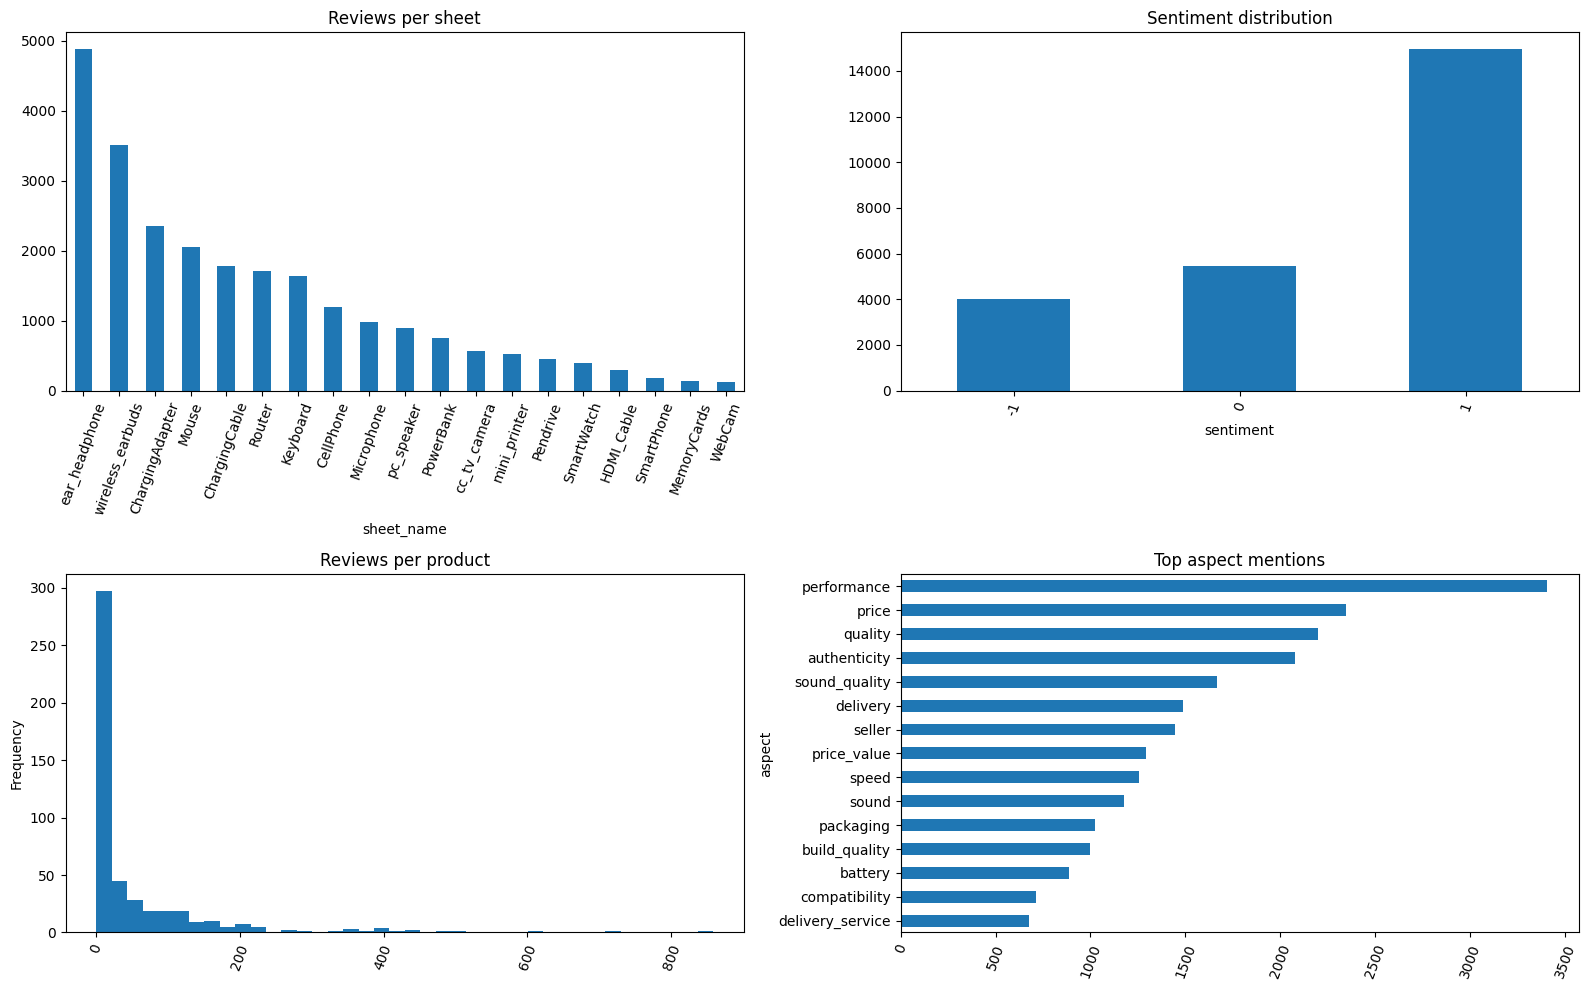

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sheet_stats['reviews'].sort_values(ascending=False).plot(kind='bar', ax=axes[0, 0], title='Reviews per sheet')
reviews_df['sentiment'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], title='Sentiment distribution')
reviews_df['product_id'].value_counts().plot(kind='hist', bins=40, ax=axes[1, 0], title='Reviews per product')
top_aspects_df.iloc[:15].sort_values('mentions').plot(kind='barh', x='aspect', y='mentions', ax=axes[1, 1], title='Top aspect mentions', legend=False)
for ax in axes.ravel(): ax.tick_params(axis='x', rotation=70)
plt.tight_layout(); plt.show()

## Split, aspects, and product profiles

In [12]:
def assign_splits(df, seed=SEED):
    rng = np.random.default_rng(seed)
    split = pd.Series('train', index=df.index, dtype='object')
    for _, g in df.groupby('product_id'):
        idx = g.index.to_numpy(); rng.shuffle(idx); n = len(idx)
        if n >= 10:
            n_test, n_val = max(1, round(n * 0.10)), max(1, round(n * 0.10))
            split.loc[idx[:n_test]] = 'test'; split.loc[idx[n_test:n_test+n_val]] = 'val'
        elif n >= 5:
            split.loc[idx[:1]] = 'test'; split.loc[idx[1:2]] = 'val'
        elif n >= 3:
            split.loc[idx[:1]] = 'test'
    return split

reviews_df['split'] = assign_splits(reviews_df)
train_df = reviews_df[reviews_df['split'] == 'train'].copy()
val_df = reviews_df[reviews_df['split'] == 'val'].copy()
test_df = reviews_df[reviews_df['split'] == 'test'].copy()

split_summary = reviews_df.groupby('split').agg(reviews=('reviews', 'size'), products=('product_id', 'nunique'))
display(split_summary)
print('train catalog products:', train_df['product_id'].nunique())

,reviews,products
split,,
test,2421,246
train,19559,483
val,2420,245


train catalog products: 483


In [13]:
ASPECT_GROUPS = {
    'sound': {'raw': ['sound', 'sound_quality', 'audio'], 'aliases': ['sound', 'audio', 'clear sound', 'speaker sound', 'সাউন্ড', 'শব্দ']},
    'bass': {'raw': ['bass', 'bass_and_loudness'], 'aliases': ['bass', 'loud', 'বেস', 'বাস']},
    'microphone': {'raw': ['mic', 'microphone'], 'aliases': ['mic', 'microphone', 'call quality', 'voice call', 'মাইক', 'কল']},
    'noise_control': {'raw': ['noise', 'noise_cancellation', 'anc_enc'], 'aliases': ['noise', 'anc', 'enc', 'noise cancellation', 'নয়েজ']},
    'battery': {'raw': ['battery'], 'aliases': ['battery', 'battery backup', 'backup', 'long battery', 'ব্যাটারি', 'ব্যাকআপ']},
    'charging_speed': {'raw': ['charging', 'charger', 'wattage', 'speed'], 'aliases': ['charging', 'fast charging', 'quick charge', 'watt', 'speed', 'চার্জ', 'ফাস্ট চার্জ']},
    'heating': {'raw': ['heat', 'heating'], 'aliases': ['heat', 'heating', 'overheat', 'hot', 'গরম', 'হিট']},
    'connectivity': {'raw': ['connectivity', 'bluetooth', 'network', 'stability', 'range', 'ports', 'connector', 'compatibility', 'data', 'app', 'software', 'firmware'], 'aliases': ['connect', 'bluetooth', 'wifi', 'network', 'range', 'stable', 'compatibility', 'usb', 'type c', 'কানেক্ট', 'ওয়াইফাই']},
    'build_quality': {'raw': ['quality', 'build', 'build_design', 'build_quality', 'build_quality_durability', 'durability', 'durability_and_quality', 'design', 'strap', 'case_accessories', 'accessories'], 'aliases': ['quality', 'build', 'durable', 'strong', 'premium', 'design', 'টেকসই', 'কোয়ালিটি', 'বিল্ড']},
    'comfort': {'raw': ['comfort', 'comfort_design', 'comfort_fit'], 'aliases': ['comfort', 'comfortable', 'fit', 'আরাম', 'কমফোর্ট']},
    'price_value': {'raw': ['price', 'price_value'], 'aliases': ['price', 'budget', 'cheap', 'affordable', 'value for money', 'কম দাম', 'কম দামে', 'বাজেট', 'সাশ্রয়ী']},
    'delivery_service': {'raw': ['delivery', 'delivery_service', 'packaging'], 'aliases': ['delivery', 'packaging', 'box', 'ডেলিভারি', 'প্যাকেজিং']},
    'seller_authenticity': {'raw': ['seller', 'authenticity', 'warranty', 'reliability', 'corruption'], 'aliases': ['seller', 'original', 'authentic', 'genuine', 'warranty', 'reliable', 'সেলার', 'অরিজিনাল', 'ওয়ারেন্টি']},
    'display_video': {'raw': ['display', 'video', 'video_quality', 'view', 'resolution', 'clarity', 'lowlight', 'night_view', 'wideangle', 'photo', 'print', 'text'], 'aliases': ['display', 'screen', 'video', 'camera', 'resolution', 'clear view', 'night vision', 'print quality', 'ডিসপ্লে', 'ক্যামেরা']},
    'performance': {'raw': ['performance', 'features', 'setup', 'security', 'sensors', 'controls', 'keys', 'click_buttons', 'scroll_wheel', 'layout', 'lighting', 'rgb_lighting', 'indicator', 'motion'], 'aliases': ['performance', 'smooth', 'feature', 'gaming', 'setup', 'sensor', 'keys', 'lighting', 'পারফরম্যান্স', 'ফিচার']},
    'storage_capacity': {'raw': ['capacity', 'size', 'paper', 'cable', 'length'], 'aliases': ['capacity', 'storage', 'memory', 'size', 'length', 'ক্যাপাসিটি', 'স্টোরেজ', 'মেমোরি']},
}

RAW2GROUP = {raw: g for g, d in ASPECT_GROUPS.items() for raw in d['raw']}

CATEGORY_ALIASES = {
    'powerbank': ['powerbank', 'power bank', 'পাওয়ার ব্যাংক', 'পাওয়ার ব্যাংক'],
    'cellphone': ['feature phone', 'button phone', 'cell phone', 'cellphone', 'বাটন ফোন'],
    'hdmi_cable': ['hdmi', 'hdmi cable'],
    'microphone': ['microphone', 'standalone mic', 'recording mic'],
    'chargingcable': ['charging cable', 'data cable', 'usb cable', 'type c cable', 'চার্জিং ক্যাবল'],
    'chargingadapter': ['adapter', 'charging adapter', 'wall charger', 'fast charger', 'চার্জার', 'অ্যাডাপ্টার'],
    'smartphone': ['smartphone', 'smart phone', 'android phone', 'স্মার্টফোন'],
    'webcam': ['webcam', 'web cam', 'ওয়েবক্যাম'],
    'smartwatch': ['smartwatch', 'smart watch', 'watch', 'ঘড়ি'],
    'mouse': ['mouse', 'মাউস'],
    'router': ['router', 'wifi router', 'wi-fi router', 'রাউটার'],
    'pendrive': ['pendrive', 'pen drive', 'usb drive', 'flash drive', 'পেনড্রাইভ'],
    'memorycards': ['memory card', 'sd card', 'micro sd', 'মেমোরি কার্ড'],
    'keyboard': ['keyboard', 'কিবোর্ড'],
    'wireless_earbuds': ['wireless earbuds', 'earbuds', 'earbud', 'tws', 'airpods', 'ইয়ারবাড', 'ইয়ারবাড'],
    'ear_headphone': ['headphone', 'headphones', 'earphone', 'earphones', 'headset', 'neckband', 'হেডফোন', 'ইয়ারফোন'],
    'mini_printer': ['mini printer', 'thermal printer', 'printer', 'প্রিন্টার'],
    'cc_tv_camera': ['cctv', 'cc tv', 'security camera', 'ip camera', 'সিসিটিভি', 'ক্যামেরা'],
    'pc_speaker': ['pc speaker', 'computer speaker', 'speaker', 'স্পিকার'],
}

SHEET_DISPLAY = {k: k.replace('_', ' ') for k in CATEGORY_ALIASES}
GROUP_PHRASES = {
    'sound': 'good sound quality', 'bass': 'strong bass', 'microphone': 'good mic for calls',
    'noise_control': 'low noise', 'battery': 'good battery backup', 'charging_speed': 'fast charging',
    'heating': 'no heating problem', 'connectivity': 'stable connection', 'build_quality': 'good build quality',
    'comfort': 'comfortable fit', 'price_value': 'good value for money', 'delivery_service': 'good delivery service',
    'seller_authenticity': 'original and reliable seller', 'display_video': 'clear display and video',
    'performance': 'smooth performance', 'storage_capacity': 'good capacity'
}

In [14]:
def positive_groups_from_row(row):
    groups = []
    for a in row['aspect_cols']:
        try:
            if int(row.get(a, 0)) == 1:
                groups.append(RAW2GROUP.get(a, a))
        except Exception:
            pass
    return list(dict.fromkeys(groups))

def strong_groups_from_stats(stats, min_mentions=2, min_quality=0.65, max_neg_rate=0.45):
    rows = []
    for g, s in stats.items():
        if s['mention'] >= min_mentions and s['quality'] >= min_quality and s['neg_rate'] <= max_neg_rate:
            rows.append((g, s['aspect_score'], s['mention']))
    return [g for g, _, _ in sorted(rows, key=lambda x: (x[1], x[2]), reverse=True)]

def build_product_catalog(df):
    rows = []
    for pid, g in df.groupby('product_id'):
        meta = g.iloc[0]
        group_counts = defaultdict(lambda: {'pos': 0, 'neg': 0, 'mention': 0})
        for a in meta['aspect_cols']:
            if a not in g.columns:
                continue
            vals = pd.to_numeric(g[a], errors='coerce').fillna(0).astype(int)
            group = RAW2GROUP.get(a, a)
            group_counts[group]['pos'] += int((vals == 1).sum())
            group_counts[group]['neg'] += int((vals == -1).sum())
            group_counts[group]['mention'] += int((vals.abs() == 1).sum())

        group_stats = {}
        for group, c in group_counts.items():
            m = max(c['mention'], 0)
            pos, neg = c['pos'], c['neg']
            quality = (pos + 1.0) / (pos + neg + 2.0)
            pos_rate = pos / m if m else 0.0
            neg_rate = neg / m if m else 0.0
            confidence = min(1.0, math.log1p(m) / math.log1p(10))
            signed_score = ((pos - neg) / m) if m else 0.0
            group_stats[group] = {
                **c,
                'quality': float(quality),
                'pos_rate': float(pos_rate),
                'neg_rate': float(neg_rate),
                'confidence': float(confidence),
                'score': float(signed_score),
                'aspect_score': float(quality * confidence),
            }

        strengths = strong_groups_from_stats(group_stats)[:8]
        weaknesses = [
            gname for gname, s in sorted(
                group_stats.items(),
                key=lambda kv: (kv[1]['neg_rate'], kv[1]['confidence'], kv[1]['mention']),
                reverse=True
            )
            if s['mention'] >= 2 and s['neg_rate'] >= 0.40
        ][:6]

        pos_snips = g[(g['sentiment'] == 1) & (~g['is_generic'])]['reviews'].drop_duplicates().head(4).tolist()
        rating = pd.to_numeric(g['overall_rating'], errors='coerce').dropna()
        price = pd.to_numeric(g['price_bdt'], errors='coerce').dropna()
        review_confidence = min(1.0, math.log1p(len(g)) / math.log1p(50))

        strength_text = ', '.join(GROUP_PHRASES.get(x, x.replace('_', ' ')) for x in strengths)
        parts = [
            f"product name: {meta['product_name']}",
            f"category: {meta['sheet_name']}",
            f"brand: {meta['brand']}" if meta['brand'] else '',
            f"price bdt: {float(price.median()):.2f}" if len(price) else '',
            f"average rating: {float(rating.mean()):.2f}" if len(rating) else '',
            f"review count: {len(g)}",
            f"strengths: {strength_text}" if strengths else '',
            'positive reviews: ' + ' || '.join(pos_snips) if pos_snips else '',
        ]

        rows.append({
            'product_id': pid,
            'sheet_name': meta['sheet_name'],
            'sheet_key': meta['sheet_name'].lower(),
            'product_name': meta['product_name'],
            'brand': meta['brand'],
            'price_bdt': float(price.median()) if len(price) else np.nan,
            'overall_rating': float(rating.mean()) if len(rating) else np.nan,
            'review_count': int(len(g)),
            'review_confidence': float(review_confidence),
            'positive_review_rate': float((g['sentiment'] == 1).mean()),
            'negative_review_rate': float((g['sentiment'] == -1).mean()),
            'aspect_group_stats': group_stats,
            'top_strength_groups': strengths,
            'top_weakness_groups': weaknesses,
            'top_strengths': ', '.join(x.replace('_', ' ') for x in strengths),
            'top_weaknesses': ', '.join(x.replace('_', ' ') for x in weaknesses),
            'profile_text': '\n'.join(p for p in parts if p),
        })
    return pd.DataFrame(rows).sort_values(
        ['sheet_name', 'review_count', 'overall_rating'],
        ascending=[True, False, False]
    ).reset_index(drop=True)

product_catalog = build_product_catalog(train_df)
display(product_catalog[['sheet_name', 'product_name', 'price_bdt', 'overall_rating', 'review_count', 'review_confidence', 'top_strengths', 'top_weaknesses']].head(10))
print('catalog products:', len(product_catalog))


,sheet_name,product_name,price_bdt,overall_rating,review_count,review_confidence,top_strengths,top_weaknesses
0,CellPhone,Symphony A30 Feature Phone,1009.0,4.6,686,1.000000,"seller authenticity, price value, charging spe...",performance
1,CellPhone,Symphony Hero 20 Feature Phone,1209.0,4.5,120,1.000000,"sound, build quality, connectivity, price valu...",
2,CellPhone,Vega V105 Dual SIM Feature Button Mobile Phone...,830.0,4.7,64,1.000000,"delivery service, build quality, price value, ...","sound, display video"
3,CellPhone,Vega V29 Dual SIM Feature Button Mobile Phone ...,870.0,4.8,40,0.944491,"build quality, price value, battery, charging ...",
4,CellPhone,4 SIM BD70 + 2.8 inch Big Display supper power...,1970.0,4.6,40,0.944491,"build quality, charging speed, seller authenti...",battery
5,ChargingAdapter,Teton 30W GaN Fast Charger Travel Charger Fast...,899.0,4.6,482,1.000000,"connectivity, price value, charging speed, sto...",heating
6,ChargingAdapter,Xiaomi (3A) Charging Adapter - White,440.0,4.3,395,1.000000,"connectivity, price value, delivery service, s...","heating, build quality"
7,ChargingAdapter,Xiaomi MI 33W Charging Adapter EU – White,680.0,4.3,321,1.000000,"connectivity, seller authenticity, delivery se...","heating, build quality"
8,ChargingAdapter,18W Fast Charger - USB Type-A Charger with USB...,379.0,4.6,283,1.000000,"connectivity, storage capacity, seller authent...",heating
9,ChargingAdapter,Anker 20W Cube PowerPort III PD USB C Fast Cha...,915.0,4.6,215,1.000000,"connectivity, charging speed, seller authentic...",


catalog products: 483


## Training pairs

In [15]:
def category_text(sheet_name):
    return SHEET_DISPLAY.get(sheet_name.lower(), sheet_name.replace('_', ' '))

def make_aspect_templates(row, max_groups=3):
    groups = positive_groups_from_row(row)[:max_groups]
    if not groups:
        return []
    cat = category_text(row['sheet_name'])
    phrases = [GROUP_PHRASES.get(g, g.replace('_', ' ')) for g in groups]
    qs = []
    for p in phrases:
        qs += [
            f'best {cat} with {p}',
            f'{cat} with {p} and good quality',
            f'value for money {cat} with {p}',
            f'{cat} চাই {p} ভালো',
            f'{cat} {p} bhalo',
        ]
    if len(phrases) >= 2:
        qs += [
            f'{cat} with {phrases[0]} and {phrases[1]}',
            f'best {cat} with {phrases[0]} and {phrases[1]}',
            f'{phrases[0]} and {phrases[1]} {cat}',
        ]
    if 'price_value' in groups:
        qs += [f'budget {cat}', f'কম দামে ভালো {cat}', f'cheap but good {cat}']
    return list(dict.fromkeys(normalize_text(q) for q in qs if normalize_text(q)))

def product_level_templates(product_row, max_groups=5):
    cat = category_text(product_row['sheet_name'])
    stats = product_row['aspect_group_stats']
    groups = strong_groups_from_stats(stats, min_mentions=2, min_quality=0.65, max_neg_rate=0.45)[:max_groups]
    qs = []
    for g in groups:
        phrase = GROUP_PHRASES.get(g, g.replace('_', ' '))
        qs += [
            f'best {cat} with {phrase}',
            f'{cat} with {phrase} and good quality',
            f'value for money {cat} with {phrase}',
            f'{cat} {phrase} bhalo',
        ]
    if len(groups) >= 2:
        p1 = GROUP_PHRASES.get(groups[0], groups[0].replace('_', ' '))
        p2 = GROUP_PHRASES.get(groups[1], groups[1].replace('_', ' '))
        qs += [
            f'best {cat} with {p1} and {p2}',
            f'{cat} with {p1} and {p2}',
        ]
    if 'price_value' in groups:
        qs += [f'budget {cat}', f'cheap but good {cat}', f'কম দামে ভালো {cat}']
    return list(dict.fromkeys(normalize_text(q) for q in qs if normalize_text(q)))

def build_training_pairs(train_reviews, catalog):
    profile = dict(zip(catalog['product_id'], catalog['profile_text']))
    rows = []
    clean_pos = train_reviews[
        (train_reviews['sentiment'] == 1)
        & (~train_reviews['is_generic'])
        & (train_reviews['aspect_signal'] > 0)
    ]

    for _, r in clean_pos.iterrows():
        pid = r['product_id']
        if pid not in profile:
            continue
        q = normalize_text(r['reviews'])
        if q and token_count(q) >= 3:
            rows.append({'query_text': q, 'product_id': pid})
        rows += [{'query_text': q, 'product_id': pid} for q in make_aspect_templates(r)]

    for _, p in catalog.iterrows():
        rows += [{'query_text': q, 'product_id': p['product_id']} for q in product_level_templates(p)]

    pairs = pd.DataFrame(rows).drop_duplicates()
    if len(pairs) > MAX_DENSE_PAIRS:
        pairs = pairs.sample(MAX_DENSE_PAIRS, random_state=SEED)
    pairs['profile_text'] = pairs['product_id'].map(profile)
    pairs = pairs.dropna().reset_index(drop=True)
    return pairs

train_pairs = build_training_pairs(train_df, product_catalog)
pid_to_idx = {pid: i for i, pid in enumerate(product_catalog['product_id'])}
train_pairs['pid_idx'] = train_pairs['product_id'].map(pid_to_idx).astype(int)
display(train_pairs.head(10))
print('dense training pairs:', len(train_pairs))


,query_text,product_id,profile_text,pid_idx
0,Power Bank was good and fast charge support কর...,powerbank::vdenmenv dp43 pd 22.5w qc3.0 10000m...,product name: VDENMENV DP43 PD 22.5W QC3.0 100...,278
1,best powerbank with fast charging,powerbank::vdenmenv dp43 pd 22.5w qc3.0 10000m...,product name: VDENMENV DP43 PD 22.5W QC3.0 100...,278
2,powerbank with fast charging and good quality,powerbank::vdenmenv dp43 pd 22.5w qc3.0 10000m...,product name: VDENMENV DP43 PD 22.5W QC3.0 100...,278
3,value for money powerbank with fast charging,powerbank::vdenmenv dp43 pd 22.5w qc3.0 10000m...,product name: VDENMENV DP43 PD 22.5W QC3.0 100...,278
4,powerbank চাই fast charging ভালো,powerbank::vdenmenv dp43 pd 22.5w qc3.0 10000m...,product name: VDENMENV DP43 PD 22.5W QC3.0 100...,278
5,powerbank fast charging bhalo,powerbank::vdenmenv dp43 pd 22.5w qc3.0 10000m...,product name: VDENMENV DP43 PD 22.5W QC3.0 100...,278
6,প্রোডাক্ট টা ভালো আছে নিতে পারেন আমি ভালোই পেয...,powerbank::vdenmenv dp43 pd 22.5w qc3.0 10000m...,product name: VDENMENV DP43 PD 22.5W QC3.0 100...,278
7,best powerbank with original and reliable seller,powerbank::vdenmenv dp43 pd 22.5w qc3.0 10000m...,product name: VDENMENV DP43 PD 22.5W QC3.0 100...,278
8,powerbank with original and reliable seller an...,powerbank::vdenmenv dp43 pd 22.5w qc3.0 10000m...,product name: VDENMENV DP43 PD 22.5W QC3.0 100...,278
9,value for money powerbank with original and re...,powerbank::vdenmenv dp43 pd 22.5w qc3.0 10000m...,product name: VDENMENV DP43 PD 22.5W QC3.0 100...,278


dense training pairs: 19196


## Dense E5 fine-tuning with early stopping

In [16]:
def model_prefix(text, is_query):
    return ('query: ' if is_query else 'passage: ') + normalize_text(text)

class E5Encoder(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        emb = (out * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        return F.normalize(emb, p=2, dim=1)

class PairDataset(Dataset):
    def __init__(self, df):
        self.q = df['query_text'].tolist(); self.d = df['profile_text'].tolist(); self.pid = df['pid_idx'].tolist()
    def __len__(self): return len(self.q)
    def __getitem__(self, i): return self.q[i], self.d[i], self.pid[i]

def make_pair_collate(tokenizer):
    def collate(batch):
        qs, ds, pids = zip(*batch)
        qt = tokenizer([model_prefix(x, True) for x in qs], padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors='pt')
        dt = tokenizer([model_prefix(x, False) for x in ds], padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors='pt')
        return qt, dt, torch.tensor(pids, dtype=torch.long)
    return collate

def unwrap(model):
    return model.module if isinstance(model, nn.DataParallel) else model

@torch.no_grad()
def encode_texts(model, tokenizer, texts, is_query, batch_size=ENCODE_BATCH_SIZE):
    model.eval(); outs = []
    for i in tqdm(range(0, len(texts), batch_size), leave=False):
        batch = [model_prefix(t, is_query) for t in texts[i:i+batch_size]]
        tok = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors='pt')
        tok = {k: v.to(DEVICE) for k, v in tok.items()}
        outs.append(model(**tok).detach().cpu().numpy())
    return np.vstack(outs).astype('float32') if outs else np.zeros((0, 768), dtype='float32')

def ranking_metrics(query_df, scores, catalog, k=10):
    pids = catalog['product_id'].tolist(); p2i = {p: i for i, p in enumerate(pids)}
    ranks = []
    for i, (_, r) in enumerate(query_df.reset_index(drop=True).iterrows()):
        if r['product_id'] not in p2i: continue
        true_i = p2i[r['product_id']]
        order = np.argsort(-scores[i])
        ranks.append(int(np.flatnonzero(order == true_i)[0] + 1))
    ranks = np.array(ranks, dtype=np.int32)
    if len(ranks) == 0:
        return {'queries': 0, 'Hit@1': 0, 'Hit@3': 0, 'Hit@5': 0, 'Hit@10': 0, 'MRR@10': 0, 'NDCG@10': 0, 'MedianRank': np.nan, 'MeanRank': np.nan}
    return {
        'queries': int(len(ranks)),
        'Hit@1': float((ranks <= 1).mean()),
        'Hit@3': float((ranks <= 3).mean()),
        'Hit@5': float((ranks <= 5).mean()),
        'Hit@10': float((ranks <= 10).mean()),
        'MRR@10': float(np.mean(np.where(ranks <= k, 1.0 / ranks, 0.0))),
        'NDCG@10': float(np.mean(np.where(ranks <= k, 1.0 / np.log2(ranks + 1), 0.0))),
        'MedianRank': float(np.median(ranks)),
        'MeanRank': float(np.mean(ranks)),
    }

def make_eval_queries(df, include_reviews=True, include_templates=False, max_templates_per_row=2):
    valid = set(product_catalog['product_id'])
    rows = []
    for _, r in df.iterrows():
        if r['product_id'] not in valid or r['sentiment'] != 1: continue
        if include_reviews and not r['is_generic'] and token_count(r['reviews']) >= 3:
            rows.append({'query_text': normalize_text(r['reviews']), 'product_id': r['product_id'], 'source': 'review'})
        if include_templates and r['aspect_signal'] > 0:
            for q in make_aspect_templates(r)[:max_templates_per_row]:
                rows.append({'query_text': q, 'product_id': r['product_id'], 'source': 'aspect_template'})
    return pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)

def evaluate_dense(model, tokenizer, query_df):
    q_emb = encode_texts(model, tokenizer, query_df['query_text'].tolist(), True)
    p_emb = encode_texts(model, tokenizer, product_catalog['profile_text'].tolist(), False)
    return ranking_metrics(query_df, q_emb @ p_emb.T, product_catalog)

In [17]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
dense_model = E5Encoder(BASE_MODEL).to(DEVICE)
if torch.cuda.device_count() > 1:
    dense_model = nn.DataParallel(dense_model)
    print('using DataParallel on', torch.cuda.device_count(), 'GPUs')

train_loader = DataLoader(
    PairDataset(train_pairs), batch_size=TRAIN_BATCH_SIZE, shuffle=True,
    collate_fn=make_pair_collate(tokenizer), num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), drop_last=True
)
optimizer = torch.optim.AdamW(dense_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * MAX_EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
val_dense_queries = make_eval_queries(val_df, include_reviews=True, include_templates=True)

best_mrr, bad_epochs = -1.0, 0
history = []
for epoch in range(1, MAX_EPOCHS + 1):
    dense_model.train(); losses_epoch = []
    pbar = tqdm(train_loader, desc=f'dense epoch {epoch}/{MAX_EPOCHS}')
    for qt, dt, pids in pbar:
        qt = {k: v.to(DEVICE, non_blocking=True) for k, v in qt.items()}
        dt = {k: v.to(DEVICE, non_blocking=True) for k, v in dt.items()}
        pids = pids.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            qe, de = dense_model(**qt), dense_model(**dt)
            logits = (qe @ de.T) / TEMPERATURE
            same = pids[:, None].eq(pids[None, :])
            logits = logits.masked_fill(same & ~torch.eye(len(pids), dtype=torch.bool, device=DEVICE), -1e4)
            loss = F.cross_entropy(logits, torch.arange(len(pids), device=DEVICE))
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(dense_model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        losses_epoch.append(float(loss.detach().cpu()))
        pbar.set_postfix(loss=np.mean(losses_epoch[-50:]))

    val_metrics = evaluate_dense(dense_model, tokenizer, val_dense_queries)
    row = {'epoch': epoch, 'train_loss': float(np.mean(losses_epoch)), **val_metrics}
    history.append(row); display(pd.DataFrame(history).tail(1))
    metric = val_metrics['MRR@10']
    if metric > best_mrr + EARLY_STOPPING_MIN_DELTA:
        best_mrr, bad_epochs = metric, 0
        MODEL_DIR.mkdir(parents=True, exist_ok=True)
        unwrap(dense_model).encoder.save_pretrained(MODEL_DIR)
        tokenizer.save_pretrained(MODEL_DIR)
        print(f'best dense model saved | MRR@10={best_mrr:.4f}')
    else:
        bad_epochs += 1
        print(f'no improvement: {bad_epochs}/{EARLY_STOPPING_PATIENCE}')
        if bad_epochs >= EARLY_STOPPING_PATIENCE:
            print('early stopping')
            break

best_dense_mrr = best_mrr
pd.DataFrame(history)

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

...

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

,epoch,train_loss,queries,Hit@1,Hit@3,Hit@5,Hit@10,MRR@10,NDCG@10,MedianRank,MeanRank
18,19,0.722505,1993,0.191169,0.313096,0.378826,0.47717,0.272029,0.320521,13.0,47.941796


no improvement: 5/5
early stopping


,epoch,train_loss,queries,Hit@1,Hit@3,Hit@5,Hit@10,MRR@10,NDCG@10,MedianRank,MeanRank
0,1,1.880473,1993,0.097842,0.199699,0.274461,0.391872,0.172831,0.223943,20.0,41.761164
1,2,1.500630,1993,0.115906,0.237331,0.320120,0.437531,0.202207,0.257420,14.0,37.172102
2,3,1.388208,1993,0.125941,0.256397,0.343703,0.455093,0.216617,0.272885,13.0,36.109383
3,4,1.261569,1993,0.148520,0.279478,0.365278,0.470146,0.237702,0.292548,13.0,36.006021
4,5,1.155569,1993,0.159057,0.296036,0.377822,0.479679,0.251613,0.305574,12.0,36.099348
5,6,1.077475,1993,0.165580,0.302559,0.380331,0.481686,0.255418,0.308956,12.0,35.628700
6,7,1.003667,1993,0.172102,0.313598,0.388359,0.493226,0.264983,0.319058,11.0,35.362770
7,8,0.943478,1993,0.178625,0.310587,0.384345,0.487707,0.266209,0.318532,11.0,38.002509
8,9,0.891998,1993,0.182639,0.318113,0.389865,0.476668,0.268682,0.318103,12.0,40.816859
9,10,0.865951,1993,0.186152,0.317110,0.388861,0.483191,0.272154,0.322178,12.0,40.543402


## Hybrid features

In [18]:
del dense_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
dense_model = E5Encoder(str(MODEL_DIR)).to(DEVICE)
if torch.cuda.device_count() > 1:
    dense_model = nn.DataParallel(dense_model)

product_embeddings = encode_texts(dense_model, tokenizer, product_catalog['profile_text'].tolist(), False)
sparse_vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=1, sublinear_tf=True)
product_sparse_matrix = sparse_vectorizer.fit_transform(product_catalog['profile_text'].tolist())

rating_values = product_catalog['overall_rating'].fillna(product_catalog['overall_rating'].median()).to_numpy('float32')
rating_feature = (rating_values - np.nanmin(rating_values)) / (np.nanmax(rating_values) - np.nanmin(rating_values) + 1e-8)

pos_values = product_catalog['positive_review_rate'].fillna(product_catalog['positive_review_rate'].median()).to_numpy('float32')
positive_rate_feature = (pos_values - np.nanmin(pos_values)) / (np.nanmax(pos_values) - np.nanmin(pos_values) + 1e-8)

product_prices = product_catalog['price_bdt'].fillna(product_catalog['price_bdt'].median()).to_numpy('float32')
price_norm = (product_prices - np.nanmin(product_prices)) / (np.nanmax(product_prices) - np.nanmin(product_prices) + 1e-8)

review_confidence_feature = product_catalog['review_confidence'].fillna(0).to_numpy('float32')

FEATURE_NAMES = [
    'dense',
    'sparse',
    'aspect',
    'category',
    'rating',
    'positive_rate',
    'price_penalty',
    'negative_aspect_penalty',
    'review_confidence',
]

MANUAL_WEIGHTS = np.array([
     0.30,   # dense
     0.15,   # sparse
     0.38,   # aspect
     0.10,   # category
     0.04,   # rating
     0.03,   # positive_rate
    -0.08,   # price_penalty
    -0.22,   # negative_aspect_penalty
     0.05,   # review_confidence
], dtype='float32')

print('product embeddings:', product_embeddings.shape)
print('sparse matrix:', product_sparse_matrix.shape)
print('features:', FEATURE_NAMES)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

product embeddings: (483, 768)
sparse matrix: (483, 47553)
features: ['dense', 'sparse', 'aspect', 'category', 'rating', 'positive_rate', 'price_penalty', 'negative_aspect_penalty', 'review_confidence']


In [19]:
def contains_alias(q, alias):
    alias = alias.lower()
    if re.search(r'[A-Za-z0-9]', alias):
        return re.search(r'(?<![a-z0-9])' + re.escape(alias) + r'(?![a-z0-9])', q) is not None
    return alias in q

def extract_query_aspects(query):
    q = normalize_text(query).lower()
    hits = []
    for g, d in ASPECT_GROUPS.items():
        if any(contains_alias(q, a) for a in d['aliases']):
            hits.append(g)
    return sorted(set(hits))

def detect_query_categories(query):
    q = normalize_text(query).lower()
    hits = []
    for cat, aliases in CATEGORY_ALIASES.items():
        if any(contains_alias(q, a) for a in aliases):
            hits.append(cat)
    return sorted(set(hits))

def parse_price_query(query):
    q = normalize_text(query).lower().translate(BANGLA_DIGITS)
    nums = [int(x) for x in re.findall(r'\d{2,7}', q)]
    has_budget = any(k in q for k in ['budget', 'cheap', 'affordable', 'low price', 'kom dam', 'kom dame', 'কম দাম', 'কম দামে', 'বাজেট', 'সাশ্রয়ী'])
    info = {'max_price': None, 'min_price': None, 'budget_query': has_budget}
    if nums and any(k in q for k in ['under', 'below', 'within', 'max', 'less than', 'টাকার মধ্যে', 'এর মধ্যে', '৳', 'tk', 'taka', 'bdt']):
        info['max_price'] = nums[0]
    if nums and any(k in q for k in ['above', 'over', 'minimum', 'at least', 'more than']):
        info['min_price'] = nums[0]
    return info

def row_minmax(x):
    mn = x.min(axis=1, keepdims=True)
    mx = x.max(axis=1, keepdims=True)
    return ((x - mn) / (mx - mn + 1e-8)).astype('float32')

def aspect_vectors(query_texts):
    aspect = np.zeros((len(query_texts), len(product_catalog)), dtype='float32')
    neg = np.zeros_like(aspect)
    for i, q in enumerate(query_texts):
        groups = extract_query_aspects(q)
        if not groups:
            continue
        for j, stats in enumerate(product_catalog['aspect_group_stats']):
            vals, negs = [], []
            for g in groups:
                if g in stats and stats[g]['mention'] > 0:
                    confidence = stats[g].get('confidence', 0.0)
                    vals.append(stats[g].get('quality', 0.5) * confidence)
                    negs.append(stats[g].get('neg_rate', 0.0) * confidence)
            aspect[i, j] = float(np.mean(vals)) if vals else 0.0
            neg[i, j] = float(np.mean(negs)) if negs else 0.0
    return aspect, neg

def category_matrix(query_texts):
    out = np.zeros((len(query_texts), len(product_catalog)), dtype='float32')
    keys = product_catalog['sheet_key'].to_numpy()
    for i, q in enumerate(query_texts):
        cats = detect_query_categories(q)
        if cats:
            out[i] = np.isin(keys, cats).astype('float32')
    return out

def price_penalty_matrix(query_texts):
    out = np.zeros((len(query_texts), len(product_catalog)), dtype='float32')
    for i, q in enumerate(query_texts):
        info = parse_price_query(q)
        if info['max_price']:
            m = max(info['max_price'], 1)
            out[i] += np.where(product_prices > m, np.minimum(1.0, (product_prices - m) / m), 0)
        if info['min_price']:
            m = max(info['min_price'], 1)
            out[i] += np.where(product_prices < m, np.minimum(1.0, (m - product_prices) / m), 0)
        if info['budget_query'] and info['max_price'] is None:
            out[i] += price_norm
    return out.astype('float32')

def compute_feature_cube(query_texts):
    if len(query_texts) == 0:
        return np.zeros((0, len(product_catalog), len(FEATURE_NAMES)), dtype='float32')
    q_dense = encode_texts(dense_model, tokenizer, query_texts, True)
    dense = row_minmax(q_dense @ product_embeddings.T)
    sparse = row_minmax(cosine_similarity(sparse_vectorizer.transform(query_texts), product_sparse_matrix).astype('float32'))
    aspect, neg = aspect_vectors(query_texts)
    cat = category_matrix(query_texts)
    price_pen = price_penalty_matrix(query_texts)
    rating = np.tile(rating_feature, (len(query_texts), 1)).astype('float32')
    pos = np.tile(positive_rate_feature, (len(query_texts), 1)).astype('float32')
    conf = np.tile(review_confidence_feature, (len(query_texts), 1)).astype('float32')
    return np.stack([dense, sparse, aspect, cat, rating, pos, price_pen, neg, conf], axis=2).astype('float32')

def manual_scores_from_features(X):
    return (X @ MANUAL_WEIGHTS).astype('float32')


## Manual baseline

In [20]:
def product_relevance_for_query(query, original_product_id=None):
    q = normalize_text(query)
    groups = extract_query_aspects(q)
    cats = detect_query_categories(q)
    price_info = parse_price_query(q)

    n = len(product_catalog)
    cat_ok = np.ones(n, dtype=bool)
    if cats:
        cat_ok = product_catalog['sheet_key'].isin(cats).to_numpy()

    aspect_sat = np.ones(n, dtype='float32')
    neg_avoid = np.ones(n, dtype=bool)
    if groups:
        aspect_sat = np.zeros(n, dtype='float32')
        neg_avoid = np.ones(n, dtype=bool)
        for j, stats in enumerate(product_catalog['aspect_group_stats']):
            vals, avoids = [], []
            for g in groups:
                s = stats.get(g)
                if s and s['mention'] > 0:
                    vals.append(s.get('quality', 0.5) * s.get('confidence', 0.0))
                    avoids.append(s.get('neg_rate', 0.0) <= 0.45)
                else:
                    vals.append(0.0)
                    avoids.append(True)
            aspect_sat[j] = float(np.mean(vals)) if vals else 1.0
            neg_avoid[j] = bool(all(avoids))

    budget_ok = np.ones(n, dtype=bool)
    if price_info['max_price'] is not None:
        budget_ok &= product_prices <= price_info['max_price']
    if price_info['min_price'] is not None:
        budget_ok &= product_prices >= price_info['min_price']

    suitable = cat_ok & neg_avoid & budget_ok
    if groups:
        suitable &= aspect_sat >= 0.35

    rel = np.zeros(n, dtype='float32')
    rel += cat_ok.astype('float32') if cats else 1.0
    rel += aspect_sat if groups else 1.0
    rel += neg_avoid.astype('float32') if groups else 1.0
    rel += budget_ok.astype('float32') if (price_info['max_price'] is not None or price_info['min_price'] is not None) else 1.0
    rel = rel / 4.0

    if original_product_id is not None:
        p2i = {p: i for i, p in enumerate(product_catalog['product_id'])}
        if original_product_id in p2i:
            rel[p2i[original_product_id]] = max(rel[p2i[original_product_id]], 1.0)

    return rel.astype('float32'), suitable

def suitability_metrics(query_df, scores, catalog, k=10):
    if len(query_df) == 0:
        return {
            'Category@1': 0, 'AspectSat@1': 0, 'NegAvoid@1': 0,
            'Budget@1': 0, 'Suitable@1': 0, 'Suitable@3': 0, 'NDCG_suit@10': 0
        }

    category_vals, aspect_vals, neg_vals, budget_vals = [], [], [], []
    suitable1, suitable3, ndcgs = [], [], []

    for i, (_, r) in enumerate(query_df.reset_index(drop=True).iterrows()):
        q = r['query_text']
        groups = extract_query_aspects(q)
        cats = detect_query_categories(q)
        price_info = parse_price_query(q)
        rel, suitable = product_relevance_for_query(q, original_product_id=None)
        order = np.argsort(-scores[i])
        top1 = order[0]
        top3 = order[:3]
        top10 = order[:10]

        if cats:
            category_vals.append(float(product_catalog.iloc[top1]['sheet_key'] in cats))
        if groups:
            stats = product_catalog.iloc[top1]['aspect_group_stats']
            vals, avoids = [], []
            for g in groups:
                s = stats.get(g)
                if s and s['mention'] > 0:
                    vals.append(s.get('quality', 0.5) * s.get('confidence', 0.0))
                    avoids.append(s.get('neg_rate', 0.0) <= 0.45)
                else:
                    vals.append(0.0)
                    avoids.append(True)
            aspect_vals.append(float(np.mean(vals)) if vals else 1.0)
            neg_vals.append(float(all(avoids)))
        if price_info['max_price'] is not None or price_info['min_price'] is not None:
            ok = True
            if price_info['max_price'] is not None:
                ok &= product_prices[top1] <= price_info['max_price']
            if price_info['min_price'] is not None:
                ok &= product_prices[top1] >= price_info['min_price']
            budget_vals.append(float(ok))

        suitable1.append(float(suitable[top1]))
        suitable3.append(float(bool(suitable[top3].any())))

        gains = rel[top10]
        dcg = float(np.sum((2 ** gains - 1) / np.log2(np.arange(2, len(gains) + 2))))
        ideal = np.sort(rel)[::-1][:10]
        idcg = float(np.sum((2 ** ideal - 1) / np.log2(np.arange(2, len(ideal) + 2))))
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

    mean_or_one = lambda x: float(np.mean(x)) if len(x) else 1.0
    return {
        'Category@1': mean_or_one(category_vals),
        'AspectSat@1': mean_or_one(aspect_vals),
        'NegAvoid@1': mean_or_one(neg_vals),
        'Budget@1': mean_or_one(budget_vals),
        'Suitable@1': float(np.mean(suitable1)),
        'Suitable@3': float(np.mean(suitable3)),
        'NDCG_suit@10': float(np.mean(ndcgs)),
    }

def reranker_scores_from_cube(X, reranker=None, blend=0.70, batch_size=8192):
    manual = manual_scores_from_features(X)
    if reranker is None:
        return manual
    reranker.eval()
    flat = torch.from_numpy(X.reshape(-1, X.shape[-1])).float()
    logits = []
    with torch.no_grad():
        for i in range(0, len(flat), batch_size):
            logits.append(reranker(flat[i:i+batch_size].to(DEVICE)).detach().cpu())
    learned = torch.cat(logits).numpy().reshape(X.shape[:2])
    return blend * row_minmax(learned) + (1 - blend) * row_minmax(manual)

def evaluate_feature_ranker(query_df, use_reranker=False, reranker=None, blend=0.70):
    X = compute_feature_cube(query_df['query_text'].tolist())
    scores = reranker_scores_from_cube(X, reranker if use_reranker else None, blend=blend)
    exact = ranking_metrics(query_df, scores, product_catalog)
    suit = suitability_metrics(query_df, scores, product_catalog)
    return {**exact, **suit}, scores

val_review_queries = make_eval_queries(val_df, include_reviews=True, include_templates=False)
test_review_queries = make_eval_queries(test_df, include_reviews=True, include_templates=False)
val_aspect_queries = make_eval_queries(val_df, include_reviews=False, include_templates=True)
test_aspect_queries = make_eval_queries(test_df, include_reviews=False, include_templates=True)

manual_rows = []
for name, qdf in [('val_review', val_review_queries), ('test_review', test_review_queries), ('val_aspect', val_aspect_queries), ('test_aspect', test_aspect_queries)]:
    m, _ = evaluate_feature_ranker(qdf)
    manual_rows.append({'set': name, **m})
display(pd.DataFrame(manual_rows))


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

,set,queries,Hit@1,Hit@3,Hit@5,Hit@10,MRR@10,NDCG@10,MedianRank,MeanRank,Category@1,AspectSat@1,NegAvoid@1,Budget@1,Suitable@1,Suitable@3,NDCG_suit@10
0,val_review,1143,0.189851,0.340332,0.396325,0.494313,0.282213,0.332697,11.0,42.500437,0.962766,0.840588,0.992331,0.50,0.967629,0.978128,0.981763
1,test_review,1183,0.208791,0.338123,0.409129,0.500423,0.294937,0.343814,10.0,44.119189,0.984694,0.827587,0.984615,0.55,0.970414,0.981403,0.980905
2,val_aspect,850,0.125882,0.334118,0.474118,0.625882,0.267754,0.352608,6.0,13.885882,0.998691,0.838188,0.991765,1.00,0.972941,0.978824,0.979651
3,test_aspect,844,0.130332,0.325829,0.456161,0.622038,0.265584,0.349624,6.0,14.343602,0.997319,0.842377,1.000000,1.00,0.977488,0.986967,0.980055


## Neural reranker with hard negatives

In [21]:
def build_reranker_xy(query_df, max_queries=MAX_RERANKER_QUERIES, chunk_size=512):
    qdf = query_df.drop_duplicates(['query_text', 'product_id']).copy()
    if len(qdf) > max_queries:
        qdf = qdf.sample(max_queries, random_state=SEED).reset_index(drop=True)

    X_rows, y_rows = [], []
    pids = product_catalog['product_id'].tolist()
    p2i = {p: i for i, p in enumerate(pids)}
    sheet_keys = product_catalog['sheet_key'].to_numpy()

    for start in tqdm(range(0, len(qdf), chunk_size), desc='reranker samples'):
        chunk = qdf.iloc[start:start + chunk_size].reset_index(drop=True)
        X = compute_feature_cube(chunk['query_text'].tolist())
        base = manual_scores_from_features(X)

        for i, r in chunk.iterrows():
            if r['product_id'] not in p2i:
                continue

            true_idx = p2i[r['product_id']]
            q = r['query_text']
            rel, suitable = product_relevance_for_query(q, original_product_id=r['product_id'])
            has_need = bool(extract_query_aspects(q) or detect_query_categories(q) or parse_price_query(q)['max_price'] is not None)

            if has_need:
                positive_idxs = np.where((rel >= 0.70) & suitable)[0].tolist()
                if true_idx not in positive_idxs:
                    positive_idxs.append(true_idx)
                positive_idxs = sorted(set(positive_idxs), key=lambda idx: -base[i, idx])[:3]
            else:
                positive_idxs = [true_idx]

            same_cat = np.where(sheet_keys == sheet_keys[true_idx])[0]
            ranked = np.argsort(-base[i])
            negative_idxs = []

            for idx in list(ranked[:120]) + list(same_cat):
                if idx in positive_idxs:
                    continue
                if has_need and rel[idx] >= 0.65:
                    continue
                if idx not in negative_idxs:
                    negative_idxs.append(idx)
                if len(negative_idxs) >= NEGATIVES_PER_QUERY:
                    break

            for idx in positive_idxs:
                X_rows.append(X[i, idx])
                y_rows.append(1.0)
            for idx in negative_idxs:
                X_rows.append(X[i, idx])
                y_rows.append(0.0)

    return np.asarray(X_rows, dtype='float32'), np.asarray(y_rows, dtype='float32')

class NeuralReranker(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(n_features),
            nn.Linear(n_features, 32), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

reranker_query_pool = pd.concat([
    train_pairs[['query_text', 'product_id']],
    make_eval_queries(train_df, include_reviews=False, include_templates=True)[['query_text', 'product_id']]
], ignore_index=True).drop_duplicates().reset_index(drop=True)

X_rr, y_rr = build_reranker_xy(reranker_query_pool)
perm = np.random.default_rng(SEED).permutation(len(y_rr))
train_idx = perm[:int(len(perm) * 0.90)]

train_loader_rr = DataLoader(
    TensorDataset(torch.from_numpy(X_rr[train_idx]), torch.from_numpy(y_rr[train_idx])),
    batch_size=1024,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_rerank_queries = pd.concat([val_review_queries, val_aspect_queries], ignore_index=True).drop_duplicates().reset_index(drop=True)
if len(val_rerank_queries) > 3000:
    val_rerank_queries = val_rerank_queries.sample(3000, random_state=SEED).reset_index(drop=True)
val_X_cube = compute_feature_cube(val_rerank_queries['query_text'].tolist())

reranker = NeuralReranker(len(FEATURE_NAMES)).to(DEVICE)
pos_weight = torch.tensor(
    [(y_rr[train_idx] == 0).sum() / max((y_rr[train_idx] == 1).sum(), 1)],
    device=DEVICE,
    dtype=torch.float32
)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_rr = torch.optim.AdamW(reranker.parameters(), lr=5e-4, weight_decay=1e-4)

best_rr_metric, bad = -1.0, 0
rr_history = []
for epoch in range(1, RERANKER_EPOCHS + 1):
    reranker.train()
    epoch_losses = []
    for xb, yb in train_loader_rr:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        optimizer_rr.zero_grad(set_to_none=True)
        loss = criterion(reranker(xb), yb)
        loss.backward()
        optimizer_rr.step()
        epoch_losses.append(float(loss.detach().cpu()))

    scores = reranker_scores_from_cube(val_X_cube, reranker=reranker)
    metrics = {**ranking_metrics(val_rerank_queries, scores, product_catalog), **suitability_metrics(val_rerank_queries, scores, product_catalog)}
    metric = metrics['NDCG_suit@10']
    row = {'epoch': epoch, 'loss': float(np.mean(epoch_losses)), **metrics}
    rr_history.append(row)
    display(pd.DataFrame(rr_history).tail(1))

    if metric > best_rr_metric + 0.0005:
        best_rr_metric, bad = metric, 0
        torch.save(reranker.state_dict(), ARTIFACT_DIR / 'neural_reranker.pt')
    else:
        bad += 1
        if bad >= RERANKER_PATIENCE:
            print('reranker early stopping')
            break

reranker.load_state_dict(torch.load(ARTIFACT_DIR / 'neural_reranker.pt', map_location=DEVICE))
best_rr_mrr = best_rr_metric
pd.DataFrame(rr_history)


reranker samples:   0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

...

,epoch,loss,queries,Hit@1,Hit@3,Hit@5,Hit@10,MRR@10,NDCG@10,MedianRank,MeanRank,Category@1,AspectSat@1,NegAvoid@1,Budget@1,Suitable@1,Suitable@3,NDCG_suit@10
18,19,0.136121,1993,0.176116,0.338685,0.434521,0.566483,0.285469,0.351782,8.0,27.143001,0.991597,0.842655,0.99534,0.5,0.966382,0.977421,0.979315


,epoch,loss,queries,Hit@1,Hit@3,Hit@5,Hit@10,MRR@10,NDCG@10,MedianRank,MeanRank,Category@1,AspectSat@1,NegAvoid@1,Budget@1,Suitable@1,Suitable@3,NDCG_suit@10
19,20,0.136598,1993,0.175113,0.336678,0.43151,0.563472,0.283652,0.349684,8.0,27.425489,0.991597,0.842468,0.99534,0.5,0.966382,0.977923,0.979523


,epoch,loss,queries,Hit@1,Hit@3,Hit@5,Hit@10,MRR@10,NDCG@10,MedianRank,MeanRank,Category@1,AspectSat@1,NegAvoid@1,Budget@1,Suitable@1,Suitable@3,NDCG_suit@10
20,21,0.134019,1993,0.176116,0.33718,0.434521,0.56297,0.284271,0.35007,8.0,27.185148,0.991597,0.84099,0.99534,0.5,0.964375,0.977923,0.979417


reranker early stopping


,epoch,loss,queries,Hit@1,Hit@3,Hit@5,Hit@10,MRR@10,NDCG@10,MedianRank,MeanRank,Category@1,AspectSat@1,NegAvoid@1,Budget@1,Suitable@1,Suitable@3,NDCG_suit@10
0,1,0.806345,1993,0.149523,0.321626,0.420973,0.552434,0.262899,0.331370,8.0,28.144506,0.992647,0.829662,0.992676,0.500000,0.966382,0.978424,0.976799
1,2,0.331092,1993,0.168590,0.340191,0.433517,0.571500,0.281704,0.350121,8.0,26.974410,0.991597,0.832038,0.994674,0.538462,0.966884,0.977923,0.977385
2,3,0.213884,1993,0.175113,0.344706,0.441545,0.572002,0.287401,0.354647,7.0,27.576016,0.991597,0.837705,0.994674,0.538462,0.966884,0.977421,0.977834
3,4,0.188994,1993,0.179127,0.341696,0.445058,0.567486,0.289269,0.355109,7.0,27.996989,0.990546,0.839944,0.995340,0.538462,0.967386,0.977923,0.977813
4,5,0.177728,1993,0.178625,0.342198,0.444054,0.563974,0.288484,0.353737,7.0,28.156548,0.990546,0.840900,0.994674,0.538462,0.966382,0.977421,0.978293
5,6,0.172091,1993,0.178123,0.339689,0.443051,0.565981,0.288379,0.354077,7.0,28.293026,0.990546,0.840777,0.995340,0.500000,0.966382,0.976919,0.978578
6,7,0.165478,1993,0.176116,0.340191,0.441044,0.565981,0.286928,0.352940,7.0,28.327647,0.990546,0.842247,0.994674,0.500000,0.966382,0.977421,0.978809
7,8,0.162495,1993,0.176116,0.338685,0.437030,0.563472,0.286029,0.351667,7.0,28.313096,0.990546,0.842505,0.994674,0.500000,0.966382,0.977421,0.978888
8,9,0.159131,1993,0.176618,0.339187,0.438033,0.564476,0.286504,0.352246,7.0,28.207727,0.990546,0.842677,0.994674,0.500000,0.966382,0.977421,0.979025
9,10,0.156955,1993,0.177120,0.339187,0.439037,0.564476,0.286406,0.352169,7.0,28.002509,0.990546,0.843451,0.994674,0.500000,0.967888,0.977923,0.978992


## Final evaluation

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

,set,queries,Hit@1,Hit@3,Hit@5,Hit@10,MRR@10,NDCG@10,MedianRank,MeanRank,Category@1,AspectSat@1,NegAvoid@1,Budget@1,Suitable@1,Suitable@3,NDCG_suit@10
0,validation_review,1143,0.215223,0.343832,0.417323,0.515311,0.301144,0.351824,10.0,37.186352,0.957447,0.842139,0.995399,0.50,0.964129,0.977253,0.980068
1,test_review,1183,0.217244,0.362637,0.429417,0.528318,0.308167,0.360416,9.0,38.042265,0.979592,0.829877,0.987692,0.55,0.965342,0.978867,0.979195
2,validation_aspect_queries,850,0.125882,0.328235,0.465882,0.627059,0.265620,0.350991,6.0,15.262353,0.998691,0.843909,0.995294,1.00,0.972941,0.976471,0.978301
3,test_aspect_queries,844,0.125592,0.316351,0.457346,0.631517,0.263806,0.350461,6.0,15.844787,0.997319,0.847224,1.000000,1.00,0.978673,0.985782,0.977797


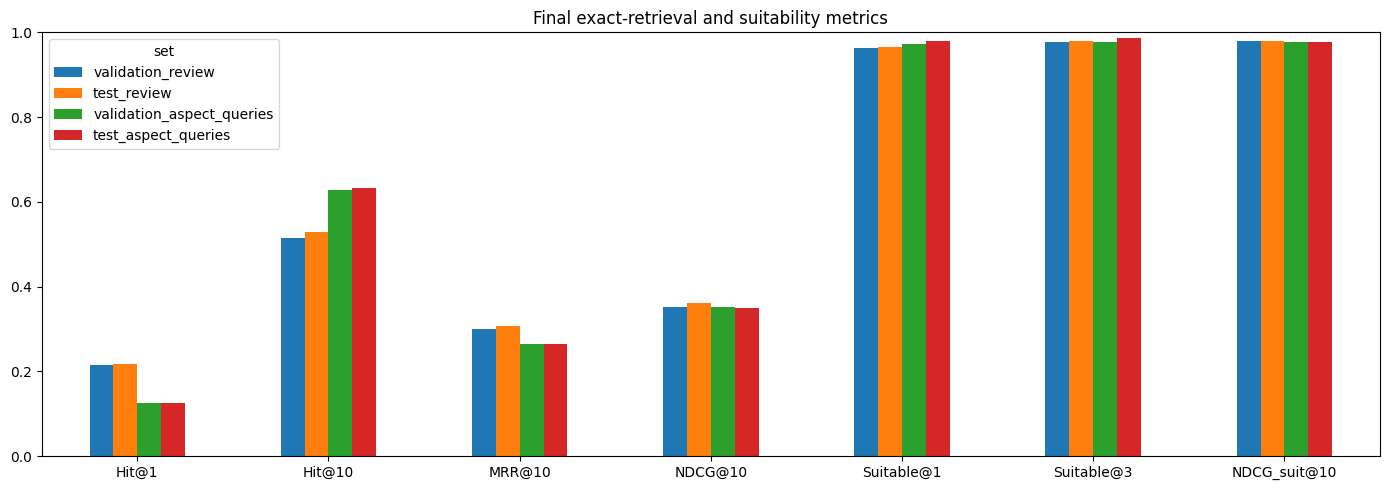

In [22]:
final_rows = []
for name, qdf in [
    ('validation_review', val_review_queries),
    ('test_review', test_review_queries),
    ('validation_aspect_queries', val_aspect_queries),
    ('test_aspect_queries', test_aspect_queries),
]:
    m, _ = evaluate_feature_ranker(qdf, use_reranker=True, reranker=reranker)
    final_rows.append({'set': name, **m})

final_evaluation = pd.DataFrame(final_rows)
display(final_evaluation)

plot_cols = ['Hit@1', 'Hit@10', 'MRR@10', 'NDCG@10', 'Suitable@1', 'Suitable@3', 'NDCG_suit@10']
plot_df = final_evaluation.set_index('set')[plot_cols]
plot_df.T.plot(kind='bar', figsize=(14, 5))
plt.ylim(0, 1)
plt.title('Final exact-retrieval and suitability metrics')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Recommendation function

In [23]:
def final_scores_for_query(query, top_k=10, use_reranker=True):
    q = normalize_text(query)
    X = compute_feature_cube([q])
    manual = manual_scores_from_features(X)[0]
    scores = row_minmax(manual.reshape(1, -1))[0]

    if use_reranker and reranker is not None:
        reranker.eval()
        with torch.no_grad():
            learned = reranker(torch.from_numpy(X[0]).float().to(DEVICE)).detach().cpu().numpy()
        scores = 0.70 * row_minmax(learned.reshape(1, -1))[0] + 0.30 * scores

    rel, _ = product_relevance_for_query(q, original_product_id=None)
    rel_norm = row_minmax(rel.reshape(1, -1))[0]
    has_aspect = bool(extract_query_aspects(q))
    scores = (0.65 * scores + 0.35 * rel_norm) if has_aspect else (0.80 * scores + 0.20 * rel_norm)

    cats = detect_query_categories(q)
    info = parse_price_query(q)
    mask = np.ones(len(product_catalog), dtype=bool)

    if cats:
        cat_mask = product_catalog['sheet_key'].isin(cats).to_numpy()
        if cat_mask.any():
            mask &= cat_mask

    if info['max_price'] is not None:
        price_mask = product_prices <= info['max_price']
        if (mask & price_mask).any():
            mask &= price_mask

    if info['min_price'] is not None:
        price_mask = product_prices >= info['min_price']
        if (mask & price_mask).any():
            mask &= price_mask

    idx = np.where(mask)[0]
    ranked = idx[np.argsort(-scores[idx])[:top_k]]
    out = product_catalog.iloc[ranked][[
        'sheet_name', 'product_name', 'brand', 'price_bdt', 'overall_rating', 'review_count',
        'positive_review_rate', 'negative_review_rate', 'top_strengths', 'top_weaknesses'
    ]].copy()
    out.insert(0, 'rank', range(1, len(out) + 1))
    out['score'] = scores[ranked]
    out['suitability_score'] = rel[ranked]
    out['matched_categories'] = ', '.join(cats)
    out['matched_aspects'] = ', '.join(extract_query_aspects(q))
    return out.reset_index(drop=True)

def recommend_products(query, top_k=10):
    print('query:', query)
    return final_scores_for_query(query, top_k=top_k)


In [24]:
display(recommend_products('wireless earbuds with good bass and mic for calling', top_k=10))
display(recommend_products('adapter with fast charging and no heating problem under 1000 taka', top_k=10))
display(recommend_products('কম দামে ভালো battery backup powerbank চাই', top_k=10))
display(recommend_products('I need a router with good range and stable connection', top_k=10))

query: wireless earbuds with good bass and mic for calling


  0%|          | 0/1 [00:00<?, ?it/s]

,rank,sheet_name,product_name,brand,price_bdt,overall_rating,review_count,positive_review_rate,negative_review_rate,top_strengths,top_weaknesses,score,suitability_score,matched_categories,matched_aspects
0,1,wireless_earbuds,AirPods Pro 2nd Gen Dubai-Made Wireless Earbud...,No brand,641.0,4.9,286,0.751748,0.066434,"build quality, sound, seller authenticity, pri...","connectivity, noise control, comfort",0.951315,0.923077,wireless_earbuds,"bass, microphone"
1,2,wireless_earbuds,Airpods Pro Wireless Earbuds Multitouch Functi...,No brand,308.0,4.3,354,0.536723,0.245763,"build quality, price value, sound, microphone,...","connectivity, battery, delivery service",0.944695,0.865720,wireless_earbuds,"bass, microphone"
2,3,wireless_earbuds,Lenovo XT88 TWS Wireless Earphone Bluetooth 5....,Lenovo,1399.0,3.9,54,0.314815,0.185185,"sound, build quality, seller authenticity, del...","battery, connectivity",0.942160,0.862847,wireless_earbuds,"bass, microphone"
3,4,wireless_earbuds,Timack® D18 Wireless Headphones Bluetooth 5.2 ...,No brand,561.0,4.2,262,0.568702,0.320611,"price value, battery, sound, build quality, co...",seller authenticity,0.937880,0.835904,wireless_earbuds,"bass, microphone"
4,5,wireless_earbuds,Style Re TWS Bluetooth Earbuds - Wireless Earp...,No brand,319.0,4.7,172,0.575581,0.238372,"price value, build quality, delivery service, ...",connectivity,0.916445,0.873419,wireless_earbuds,"bass, microphone"
5,6,wireless_earbuds,Airpods Pro 2nd generation | Pop Up | Made In ...,No brand,459.0,4.6,74,0.540541,0.243243,"price value, microphone, battery, comfort","seller authenticity, sound, connectivity, deli...",0.914675,0.807813,wireless_earbuds,"bass, microphone"
6,7,wireless_earbuds,Lenovo LP40 Pro TWS Earphones Wireless Bluetoo...,Lenovo,1039.0,4.1,49,0.714286,0.142857,"build quality, sound, seller authenticity, pri...","connectivity, delivery service",0.894337,0.807813,wireless_earbuds,"bass, microphone"
7,8,wireless_earbuds,FreePods 4 ANC True Wireless Earbuds,oraimo,4099.0,4.5,60,0.716667,0.150000,"delivery service, build quality, price value, ...",comfort,0.877820,0.880655,wireless_earbuds,"bass, microphone"
8,9,wireless_earbuds,Ultrapods Max True Wireless Earbuds with Trans...,No brand,240.0,4.6,106,0.490566,0.245283,"build quality, sound, price value, delivery se...","connectivity, battery, seller authenticity",0.873871,0.792952,wireless_earbuds,"bass, microphone"
9,10,wireless_earbuds,Airpods Pro / tws wireless earbuds Bluetooth b...,No brand,286.0,4.6,43,0.395349,0.000000,"delivery service, price value, bass","connectivity, seller authenticity, battery, sound",0.858570,0.817041,wireless_earbuds,"bass, microphone"


query: adapter with fast charging and no heating problem under 1000 taka


  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

,rank,sheet_name,product_name,brand,price_bdt,overall_rating,review_count,positive_review_rate,negative_review_rate,top_strengths,top_weaknesses,score,suitability_score,matched_categories,matched_aspects
0,1,PowerBank,JOYROOM JR-PBF12 LED Monitor 2.4A 10000mAh Pow...,STI,835.0,4.8,152,0.743421,0.138158,"build quality, price value, seller authenticit...",,0.998564,0.867188,powerbank,"battery, price_value"
1,2,PowerBank,Awei P10K 10000mAh Fast Charing Powerbank 22.5...,Awei,1049.0,4.9,55,0.800000,0.054545,"build quality, charging speed, seller authenti...",,0.994286,0.859120,powerbank,"battery, price_value"
2,3,PowerBank,JOYROOM PBF12 2.4A LED Power Bank 12W 10000mAh,Joyroom,837.0,4.8,276,0.684783,0.112319,"delivery service, price value, build quality, ...","heating, charging speed, performance",0.961843,0.859091,powerbank,"battery, price_value"
3,4,PowerBank,VDENMENV DP43 PD 22.5W QC3.0 10000mAh Power Ba...,Vdenmenv,1189.0,4.7,116,0.603448,0.215517,"build quality, charging speed, delivery servic...","storage capacity, heating",0.919320,0.843750,powerbank,"battery, price_value"


query: I need a router with good range and stable connection


  0%|          | 0/1 [00:00<?, ?it/s]

,rank,sheet_name,product_name,brand,price_bdt,overall_rating,review_count,positive_review_rate,negative_review_rate,top_strengths,top_weaknesses,score,suitability_score,matched_categories,matched_aspects
0,1,Router,Cudy M1300 (1-Pack) AC1200 Dual Band Whole Hom...,Cudy,3530.0,4.5,54,0.685185,0.166667,"price value, connectivity, seller authenticity...","heating, delivery service",0.999196,0.931818,router,connectivity
1,2,Router,TP-Link Archer C6 - AC1200 Dual WiFi Router 5 ...,Tp_Link,3495.0,4.7,98,0.663265,0.030612,"price value, seller authenticity, delivery ser...",heating,0.958265,0.931034,router,connectivity
2,3,Router,Mercusys Mr30g Ac1200 Wireless Dual Band Gigab...,Mercusys,2212.0,4.4,69,0.318841,0.014493,"price value, delivery service, seller authenti...",,0.941515,0.933333,router,connectivity
3,4,Router,Mercusys MR80X V2.2 AX3000 Dual-Band Wi-Fi 6 G...,Mercusys,3908.0,4.7,91,0.219780,0.000000,"charging speed, price value, seller authentici...",heating,0.882532,0.925000,router,connectivity
4,5,Router,Mercusys MW325R 300Mbps Enhanced Wireless N Ro...,Mercusys,1287.0,4.5,88,0.738636,0.022727,"seller authenticity, price value, delivery ser...",charging speed,0.866377,0.883432,router,connectivity
5,6,Router,TP-Link Deco E4 AC1200 Mesh Wi-Fi Router Pack ...,Tp_Link,8119.0,4.8,1,1.000000,0.000000,connectivity,,0.855250,0.835904,router,connectivity
6,7,Router,TP-Link Deco E4 AC1200 Mesh Wi-Fi Router Pack ...,Tp_Link,8119.0,4.8,1,1.000000,0.000000,connectivity,,0.852494,0.835904,router,connectivity
7,8,Router,TP-Link Deco E4 AC1200 Mesh Wi-Fi Router Pack ...,Tp_Link,8119.0,4.8,1,1.000000,0.000000,"connectivity, seller authenticity, delivery se...",,0.847679,0.835904,router,connectivity
8,9,Router,Cudy WR1200 AC1200 Dual Band Smart Wi-Fi Route...,Cudy,2347.0,4.6,174,0.649425,0.045977,"seller authenticity, price value, delivery ser...",heating,0.829548,0.901042,router,connectivity
9,10,Router,ASUS RT-N12 Plus Wireless N 3 in1 Router,Asus,2880.0,4.4,10,0.800000,0.000000,,price value,0.827141,0.798177,router,connectivity


In [26]:
display(recommend_products('kom dame valo keyboard', top_k=10))

query: kom dame valo keyboard


  0%|          | 0/1 [00:00<?, ?it/s]

,rank,sheet_name,product_name,brand,price_bdt,overall_rating,review_count,positive_review_rate,negative_review_rate,top_strengths,top_weaknesses,score,suitability_score,matched_categories,matched_aspects
0,1,Keyboard,Desktop USB Keyboard - Black,A.tech.,352.0,4.2,156,0.506410,0.147436,"price value, performance, build quality, selle...",connectivity,1.000000,1.0,keyboard,
1,2,Keyboard,Ultra-Slim Designed Usb Computer Desktop Keybo...,No_Brand,369.0,4.3,158,0.575949,0.177215,"price value, performance, delivery service","connectivity, build quality",0.976878,1.0,keyboard,
2,3,Keyboard,Wireless Keyboard and Mouse Set: Compact Bluet...,Nadra,1149.0,4.4,105,0.523810,0.257143,performance,"connectivity, build quality, price value, deli...",0.963048,1.0,keyboard,
3,4,Keyboard,FANTECH K612 SOLDIER 104 Keys 19 Buttons Have ...,FanTech,2500.0,4.7,107,0.682243,0.102804,"price value, performance, seller authenticity",build quality,0.951726,1.0,keyboard,
4,5,Keyboard,Gaming mouse and keyboard combo g21 rgb keyboa...,No_Brand,1299.0,4.8,72,0.694444,0.055556,"performance, price value, delivery service, se...",connectivity,0.939605,1.0,keyboard,
5,6,Keyboard,FANTECH ATOM63 MK874 V2 MECHANICAL GAMING KEYB...,FanTech,2390.0,4.8,23,0.826087,0.043478,"performance, build quality, noise control, pri...",,0.934654,1.0,keyboard,
6,7,Keyboard,FANTECH GO K211 Smooth Typing Keyboard 104 Key...,FanTech,440.0,4.4,34,0.588235,0.205882,"price value, performance, build quality","seller authenticity, delivery service",0.930813,1.0,keyboard,
7,8,Keyboard,A4tech KRS-82 USB Wired Keyboard - Bangla Layo...,A4Tech,990.0,4.7,127,0.763780,0.078740,"seller authenticity, delivery service, perform...",connectivity,0.921531,1.0,keyboard,
8,9,Keyboard,I-Crown I-101 USB Wired Keyboard,Aptech,500.0,4.5,95,0.221053,0.000000,"price value, delivery service, build quality, ...",connectivity,0.909502,1.0,keyboard,
9,10,Keyboard,FANTECH ATOM81 MK875V2 Mechanical Gaming Keybo...,FanTech,2550.0,4.9,17,0.764706,0.058824,"performance, price value, build quality, noise...",,0.905090,1.0,keyboard,


## Save artifacts

In [25]:
product_catalog.to_pickle(ARTIFACT_DIR / 'product_catalog.pkl')
np.save(ARTIFACT_DIR / 'product_embeddings.npy', product_embeddings)
joblib.dump(sparse_vectorizer, ARTIFACT_DIR / 'sparse_vectorizer.joblib')
joblib.dump(MANUAL_WEIGHTS, ARTIFACT_DIR / 'manual_weights.joblib')
with open(ARTIFACT_DIR / 'feature_names.json', 'w', encoding='utf-8') as f:
    json.dump(FEATURE_NAMES, f, ensure_ascii=False, indent=2)
with open(ARTIFACT_DIR / 'run_config.json', 'w', encoding='utf-8') as f:
    json.dump({
        'dataset_path': str(DATA_PATH),
        'base_model': BASE_MODEL,
        'dense_learning_rate': LEARNING_RATE,
        'reranker_learning_rate': 5e-4,
        'max_epochs': MAX_EPOCHS,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'dense_best_mrr': best_dense_mrr,
        'reranker_best_ndcg_suit': best_rr_mrr,
        'top_k': TOP_K,
        'feature_names': FEATURE_NAMES
    }, f, ensure_ascii=False, indent=2)
print('saved model:', MODEL_DIR)
print('saved artifacts:', ARTIFACT_DIR)
print(sorted(p.name for p in ARTIFACT_DIR.iterdir()))


saved model: /kaggle/working/hybrid_aspect_recommender/dense_e5_best
saved artifacts: /kaggle/working/hybrid_aspect_recommender/artifacts
['feature_names.json', 'manual_weights.joblib', 'neural_reranker.pt', 'product_catalog.pkl', 'product_embeddings.npy', 'run_config.json', 'sparse_vectorizer.joblib']
